# Fingerprint Enhancement System

**BMDS2133 Image Processing — Mode A: Comparative & Enhancement Study**

This notebook is the complete, executable academic submission. Its objective is fingerprint **enhancement**, not identity recognition: degraded or low-quality ridge flow is clarified while ridge structure is preserved to support optional later feature analysis. Restarting the kernel and running all cells recomputes every key result directly from `data/`; historical experiment CSV/JSON files are not experimental inputs.

## 2. Imports and global configuration

In [1]:
from pathlib import Path
from time import perf_counter
import json, math, platform, sys
import cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage as ndi, signal
from skimage import exposure, filters, measure, morphology, restoration, transform
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if not (ROOT / 'data' / 'SOCOFing').is_dir():
    raise FileNotFoundError('Run this notebook with its project directory as the working directory.')
DATA = ROOT / 'data' / 'SOCOFing'; REAL_DIR = DATA / 'Real'; ALTERED_DIR = DATA / 'Altered'; OUT = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)
SEED = 20260902; HOLDOUT_SEED = 20260903; NOISE_SEED_BASE = 20260903; ALTERED_SEED = 20260904
BENCHMARK_PSNR = 28.17; FINAL_NLM_H = 0.06; CONTROLLED_SEVERITY = 0.55; GAUSSIAN_SIGMA = 0.018 + 0.055 * CONTROLLED_SEVERITY
np.random.seed(SEED)
print({'Python': sys.version.split()[0], 'OpenCV': cv2.__version__, 'NumPy': np.__version__, 'platform': platform.platform(),
       'NLM backend': 'cv2.fastNlMeansDenoising', 'h_normalised': FINAL_NLM_H, 'sigma': GAUSSIAN_SIGMA})

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\TARUMT\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


{'Python': '3.11.7', 'OpenCV': '4.11.0', 'NumPy': '1.26.4', 'platform': 'Windows-10-10.0.22000-SP0', 'NLM backend': 'cv2.fastNlMeansDenoising', 'h_normalised': 0.06, 'sigma': 0.04825}


## 3. Dataset loading

SOCOFing contains clean `Real` captures and independently altered Easy, Medium and Hard images. The Altered images are evaluated without claiming pixel-aligned Real↔Altered ground truth.

,split,count,representative_path
0,Real,6000,data\SOCOFing\Real\100__M_Left_index_finger.BMP
1,Easy,17931,data\SOCOFing\Altered\Altered-Easy\100__M_Left...
2,Medium,17067,data\SOCOFing\Altered\Altered-Medium\100__M_Le...
3,Hard,14272,data\SOCOFing\Altered\Altered-Hard\100__M_Left...


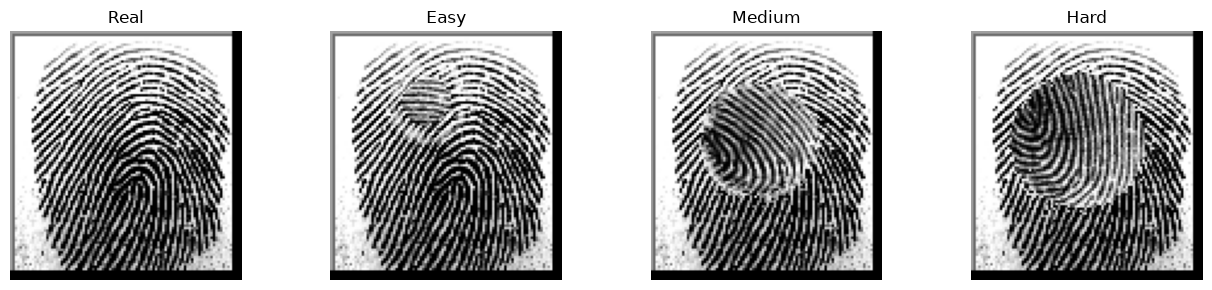

In [2]:
SUPPORTED_EXTENSIONS = {'.bmp', '.png', '.jpg', '.jpeg', '.tif', '.tiff'}
def list_images(folder):
    return sorted((p for p in Path(folder).iterdir() if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS), key=lambda p: p.name.lower())
dataset_paths = {'Real': list_images(REAL_DIR),
 'Easy': list_images(ALTERED_DIR/'Altered-Easy'), 'Medium': list_images(ALTERED_DIR/'Altered-Medium'), 'Hard': list_images(ALTERED_DIR/'Altered-Hard')}
dataset_inventory = pd.DataFrame([{'split': k, 'count': len(v), 'representative_path': str(v[0].relative_to(ROOT))} for k,v in dataset_paths.items()])
display(dataset_inventory)
fig, axes = plt.subplots(1,4,figsize=(13,3));
for ax,(name,paths) in zip(axes,dataset_paths.items()):
    ax.imshow(Image.open(paths[0]).convert('L'), cmap='gray'); ax.set_title(name); ax.axis('off')
plt.tight_layout(); plt.show()

## 4. P0 neutral preprocessing

P0 performs only grayscale conversion, 256×256 resizing and 1st/99th percentile intensity preparation. It contains no enhancement.

In [3]:
from __future__ import annotations


import math
from pathlib import Path
from typing import Any
import cv2
import numpy as np
from PIL import Image
from scipy import ndimage as ndi, signal
from skimage import exposure, filters, morphology, restoration, transform
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity

IMAGE_SIZE = (256, 256)
FINAL_NLM_H = 0.06
NLM_TEMPLATE_WINDOW_SIZE = 7
NLM_SEARCH_WINDOW_SIZE = 21
SUPPORTED_EXTENSIONS = {".bmp", ".png", ".jpg", ".jpeg", ".tif", ".tiff"}


def _metric_image(image: np.ndarray) -> np.ndarray:
    base = np.asarray(image, dtype=np.float32)
    return np.clip(np.nan_to_num(base, nan=0.0, posinf=1.0, neginf=0.0), 0.0, 1.0)


def normalise_image(image: np.ndarray, low_percentile: float = 1.0, high_percentile: float = 99.0) -> np.ndarray:
    """Percentile-normalize an image to float32 [0, 1]."""
    base = np.asarray(image, dtype=np.float32)
    low, high = np.percentile(base, [low_percentile, high_percentile])
    return _metric_image(base if high - low < 1e-8 else (base - low) / (high - low))


def preprocess_p0(image: np.ndarray, output_size: tuple[int, int] = IMAGE_SIZE) -> np.ndarray:
    """Neutral P0: grayscale, consistent resizing, and intensity normalization."""
    source = np.asarray(image)
    array = source
    if array.ndim == 3:
        array = cv2.cvtColor(array, cv2.COLOR_RGBA2GRAY if array.shape[2] == 4 else cv2.COLOR_RGB2GRAY)
    if array.ndim != 2:
        raise ValueError(f"Expected a 2-D grayscale or 3-D colour image, got {array.shape}.")
    array = array.astype(np.float32)
    if np.issubdtype(source.dtype, np.integer):
        array /= float(np.iinfo(source.dtype).max)
    elif array.max(initial=0.0) > 1.0:
        array /= 255.0
    if output_size and array.shape != tuple(output_size):
        array = transform.resize(array, output_size, anti_aliasing=True, preserve_range=True)
    return normalise_image(array)


def load_fingerprint(path: str | Path, output_size: tuple[int, int] = IMAGE_SIZE) -> np.ndarray:
    """Load a fingerprint using the exact validated P0 file path."""
    source = Path(path)
    if not source.is_file():
        raise FileNotFoundError(f"Fingerprint image not found: {source}")
    if source.suffix.lower() not in SUPPORTED_EXTENSIONS:
        raise ValueError(f"Unsupported image extension: {source.suffix}")
    with Image.open(source) as pil_image:
        image = np.asarray(pil_image.convert("L"), dtype=np.float32) / 255.0
    image = transform.resize(image, output_size, anti_aliasing=True, preserve_range=True)
    return normalise_image(image)


def apply_gaussian(image: np.ndarray, sigma: float = 0.65) -> np.ndarray:
    return _metric_image(ndi.gaussian_filter(_metric_image(image), sigma=float(sigma)))


def apply_median(image: np.ndarray, size: int = 3) -> np.ndarray:
    return _metric_image(ndi.median_filter(_metric_image(image), size=int(size)))


def apply_clahe(image: np.ndarray, clip_limit: float = 0.005, kernel_size: int = 32) -> np.ndarray:
    """Apply CLAHE as a conventional baseline."""
    return _metric_image(exposure.equalize_adapthist(_metric_image(image), clip_limit=clip_limit, kernel_size=kernel_size))


def apply_contrast_stretching(image: np.ndarray, low: float = 1.0, high: float = 99.0) -> np.ndarray:
    base = _metric_image(image); lo, hi = np.percentile(base, [low, high])
    return base.copy() if hi - lo < 1e-8 else _metric_image((base - lo) / (hi - lo))


def apply_nlm(image: np.ndarray, h: float = FINAL_NLM_H) -> np.ndarray:
    """Exact validated OpenCV NLM: round-to-uint8, windows 7/21, back to float32."""
    base = _metric_image(image)
    as_uint8 = np.round(base * 255.0).astype(np.uint8)
    filtered = cv2.fastNlMeansDenoising(as_uint8, None, h=float(h) * 255.0,
                                        templateWindowSize=7, searchWindowSize=21)
    return _metric_image(filtered.astype(np.float32) / 255.0)


def apply_tv_restoration(image: np.ndarray, weight: float = 0.02) -> np.ndarray:
    """Frozen Member 3 total-variation restoration."""
    return _metric_image(restoration.denoise_tv_chambolle(_metric_image(image), weight=weight, channel_axis=None))


def _fingerprint_mask(image: np.ndarray, block_size: int = 17) -> np.ndarray:
    base = _metric_image(image)
    mean = ndi.uniform_filter(base, size=block_size, mode="reflect")
    std = np.sqrt(np.maximum(ndi.uniform_filter(base * base, size=block_size, mode="reflect") - mean * mean, 0))
    threshold = max(0.012, float(np.percentile(std, 70) * 0.55))
    mask = (std > threshold) | ((base < np.percentile(base, 92)) & (std > threshold * 0.55))
    mask = morphology.opening(morphology.closing(mask, morphology.disk(5)), morphology.disk(2))
    mask = ndi.binary_fill_holes(mask)
    mask = morphology.remove_small_holes(mask.astype(bool), area_threshold=600)
    return morphology.remove_small_objects(mask, min_size=600)


def _orientation_field(image: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    gx, gy = filters.sobel_h(image), filters.sobel_v(image)
    gxx, gyy = ndi.gaussian_filter(gx * gx, 2), ndi.gaussian_filter(gy * gy, 2)
    gxy = ndi.gaussian_filter(gx * gy, 2)
    orientation = 0.5 * np.arctan2(2 * gxy, gxx - gyy)
    coherence = np.sqrt((gxx - gyy) ** 2 + 4 * gxy ** 2) / (gxx + gyy + 1e-8)
    return orientation.astype(np.float32), coherence.astype(np.float32)


def _frequency_map(image: np.ndarray, mask: np.ndarray, frequencies: tuple[float, ...], block_size: int = 32) -> tuple[np.ndarray, np.ndarray]:
    freq_map = np.full_like(image, np.median(frequencies), dtype=np.float32)
    confidence = np.zeros_like(image, dtype=np.float32)
    window = np.outer(np.hanning(block_size), np.hanning(block_size))
    for row in range(0, image.shape[0] - block_size + 1, block_size):
        for col in range(0, image.shape[1] - block_size + 1, block_size):
            if np.mean(mask[row:row+block_size, col:col+block_size]) < .2:
                continue
            block = image[row:row+block_size, col:col+block_size]
            spectrum = np.abs(np.fft.fftshift(np.fft.fft2((block - block.mean()) * window)))
            yy, xx = np.mgrid[:block_size, :block_size]
            radius = np.sqrt((yy-block_size/2)**2 + (xx-block_size/2)**2) / block_size
            scores = [float(np.mean(spectrum[np.abs(radius-f) < .012])) for f in frequencies]
            best = int(np.argmax(scores)); region = np.s_[row:row+block_size, col:col+block_size]
            freq_map[region] = frequencies[best]
            confidence[region] = min(scores[best] / (float(np.mean(scores)) + 1e-8) / 25, 1)
    return freq_map, confidence


def apply_modified_gabor(image: np.ndarray, frequencies: tuple[float, ...] = (.075, .095, .115, .140),
                         orientation_bins: int = 8, blend: float = .18) -> np.ndarray:
    """Frozen Member 2 local-orientation/local-frequency adaptive Gabor."""
    base = _metric_image(image); mask = _fingerprint_mask(base)
    orientation, coherence = _orientation_field(base)
    freq_map, freq_confidence = _frequency_map(base, mask, frequencies)
    bins = np.linspace(0, np.pi, orientation_bins, endpoint=False)
    oi = np.argmin(np.abs(np.angle(np.exp(1j*(orientation[..., None]-bins)))), axis=2)
    fi = np.argmin(np.abs(freq_map[..., None]-np.asarray(frequencies)), axis=2)
    selected = np.zeros_like(base); inverted = 1-base
    for f_index, frequency in enumerate(frequencies):
        for o_index, theta in enumerate(bins):
            real, imag = filters.gabor(inverted, frequency=frequency, theta=theta, bandwidth=1.8)
            response = np.sqrt(real**2 + imag**2); selector = (oi == o_index) & (fi == f_index) & mask
            selected[selector] = response[selector]
    ridge = np.where(mask, 1-normalise_image(selected), base)
    confidence = np.clip(coherence * (.5 + .5*freq_confidence), 0, 1) * mask
    return _metric_image((1-blend*confidence)*base + blend*confidence*ridge)


def apply_ordinary_gabor(image: np.ndarray, frequency: float = .115, orientations: int = 8, blend: float = .30) -> np.ndarray:
    base = _metric_image(image); responses = []
    for theta in np.linspace(0, np.pi, orientations, endpoint=False):
        real, imag = filters.gabor(1-base, frequency=frequency, theta=theta)
        responses.append(np.sqrt(real**2 + imag**2))
    return _metric_image((1-blend)*base + blend*(1-normalise_image(np.max(responses, axis=0))))


def apply_wiener(image: np.ndarray, window_size: int = 5) -> np.ndarray:
    return _metric_image(signal.wiener(_metric_image(image), mysize=window_size))


def _oriented_kernel(theta: float) -> np.ndarray:
    axis = np.arange(9, dtype=np.float32)-4; xx, yy = np.meshgrid(axis, axis)
    c, s = math.cos(theta), math.sin(theta); xr, yr = c*xx+s*yy, -s*xx+c*yy
    kernel = np.exp(-(xr**2/(2*1.35**2) + yr**2/(2*.50**2)))
    return (kernel/kernel.sum()).astype(np.float32)


def apply_coherence_guided_directional_diffusion(image: np.ndarray, iterations: int = 4, step: float = .16) -> np.ndarray:
    """Frozen Member 4 coherence-guided directional diffusion."""
    current = _metric_image(image); mask = _fingerprint_mask(current)
    bins = np.linspace(0, np.pi, 8, endpoint=False)
    for _ in range(iterations):
        orientation, coherence = _orientation_field(current)
        indexes = np.argmin(np.abs(np.angle(np.exp(1j*(orientation[..., None]-bins)))), axis=2)
        smoothed = np.zeros_like(current)
        for index, theta in enumerate(bins):
            conv = ndi.convolve(current, _oriented_kernel(theta), mode="reflect")
            smoothed[indexes == index] = conv[indexes == index]
        weight = np.clip(coherence, 0, 1)*mask
        current = _metric_image((1-step*weight)*current + step*weight*smoothed)
    return current


def segment_fingerprint(image: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    base = _metric_image(image); mask = _fingerprint_mask(base)
    return (base < filters.threshold_sauvola(base, window_size=25, k=.16)) & mask, mask


def morphological_cleanup(binary: np.ndarray, min_size: int = 24) -> np.ndarray:
    cleaned = morphology.closing(np.asarray(binary, bool), morphology.disk(1))
    return morphology.remove_small_objects(morphology.remove_small_holes(cleaned, area_threshold=28), min_size=min_size)


def thin_ridges(binary: np.ndarray) -> np.ndarray:
    return morphology.skeletonize(np.asarray(binary, bool))


def medial_axis_analysis(binary: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    return morphology.medial_axis(np.asarray(binary, bool), return_distance=True)


def extract_minutiae_detections(skeleton: np.ndarray, mask: np.ndarray | None = None, border_margin: int = 8) -> dict[str, np.ndarray]:
    skel = np.asarray(skeleton, bool); padded = np.pad(skel, 1)
    n = [padded[:-2,1:-1], padded[:-2,2:], padded[1:-1,2:], padded[2:,2:],
         padded[2:,1:-1], padded[2:,:-2], padded[1:-1,:-2], padded[:-2,:-2]]
    crossing = np.sum(np.abs(np.diff(np.stack(n+[n[0]]).astype(np.int8), axis=0)), axis=0)/2
    valid = skel.copy(); valid[:border_margin] = valid[-border_margin:] = False
    valid[:, :border_margin] = valid[:, -border_margin:] = False
    if mask is not None and np.any(mask):
        valid &= morphology.binary_erosion(np.asarray(mask, bool), morphology.disk(border_margin))
    return {"ridge_endings": np.argwhere(valid & (crossing == 1)),
            "bifurcations": np.argwhere(valid & (crossing == 3))}


def calculate_mse(reference: np.ndarray, candidate: np.ndarray) -> float:
    return float(mean_squared_error(_metric_image(reference), _metric_image(candidate)))


def calculate_psnr(reference: np.ndarray, candidate: np.ndarray) -> float:
    return float(peak_signal_noise_ratio(_metric_image(reference), _metric_image(candidate), data_range=1.0))


def calculate_ssim(reference: np.ndarray, candidate: np.ndarray) -> float:
    return float(structural_similarity(_metric_image(reference), _metric_image(candidate), data_range=1.0))


def calculate_ridge_coherence(image: np.ndarray, mask: np.ndarray | None = None) -> float:
    _, coherence = _orientation_field(_metric_image(image)); region = _fingerprint_mask(image) if mask is None else mask
    return float(np.mean(coherence[region])) if np.any(region) else float(np.mean(coherence))


def calculate_local_contrast(image: np.ndarray, mask: np.ndarray | None = None, size: int = 17) -> float:
    base = _metric_image(image); mean = ndi.uniform_filter(base, size=size, mode="reflect")
    std = np.sqrt(np.maximum(ndi.uniform_filter(base*base, size=size, mode="reflect")-mean*mean, 0))
    region = _fingerprint_mask(base) if mask is None else mask
    return float(np.mean(std[region])) if np.any(region) else float(np.mean(std))


def calculate_fragmentation(image: np.ndarray) -> float:
    ridges, _ = segment_fingerprint(image); _, count = ndi.label(ridges)
    return float(count*1000/max(np.count_nonzero(ridges), 1))


def enhance_fingerprint(image: np.ndarray, method: str = "nlm", *, assume_preprocessed: bool = False,
                        **kwargs: Any) -> tuple[np.ndarray, dict[str, Any]]:
    """GUI-ready enhancement dispatcher returning image and processing metadata."""
    base = _metric_image(image) if assume_preprocessed else preprocess_p0(image)
    methods = {"nlm": apply_nlm, "modified_gabor": apply_modified_gabor, "tv": apply_tv_restoration,
               "directional_diffusion": apply_coherence_guided_directional_diffusion,
               "gaussian": apply_gaussian, "median": apply_median, "clahe": apply_clahe,
               "contrast_stretching": apply_contrast_stretching, "ordinary_gabor": apply_ordinary_gabor,
               "wiener": apply_wiener}
    key = method.lower().strip()
    if key not in methods:
        raise ValueError(f"Unknown method '{method}'. Available: {', '.join(sorted(methods))}")
    enhanced = methods[key](base, **kwargs)
    metadata: dict[str, Any] = {"method": key, "preprocessing": "P0 already supplied" if assume_preprocessed else "P0",
                                "input_shape": tuple(base.shape), "output_shape": tuple(enhanced.shape),
                                "dtype": str(enhanced.dtype)}
    if key == "nlm":
        metadata.update({"recommended": True, "h_normalized": float(kwargs.get("h", FINAL_NLM_H)),
                         "backend": "cv2.fastNlMeansDenoising", "template_window_size": 7,
                         "search_window_size": 21})
    return enhanced, metadata


def apply_final_enhancement(image: np.ndarray, *, assume_preprocessed: bool = False) -> tuple[np.ndarray, dict[str, Any]]:
    """Apply the frozen final recommendation: OpenCV NLM, h=0.06."""
    return enhance_fingerprint(image, "nlm", assume_preprocessed=assume_preprocessed, h=FINAL_NLM_H)

In [4]:
# Exact frozen M2/M4 comparison implementations recovered from screening24_master_audit.py.
# They intentionally override the later reusable-core copies above; no parameter is retuned.
def estimate_orientation_field(image, smoothing_sigma=3.0, orientation_smoothing_sigma=2.0):
    base=_metric_image(image); gx,gy=filters.sobel_h(base),filters.sobel_v(base)
    gxx=ndi.gaussian_filter(gx*gx,smoothing_sigma);gyy=ndi.gaussian_filter(gy*gy,smoothing_sigma);gxy=ndi.gaussian_filter(gx*gy,smoothing_sigma)
    sin2=ndi.gaussian_filter(2*gxy,orientation_smoothing_sigma);cos2=ndi.gaussian_filter(gxx-gyy,orientation_smoothing_sigma)
    return 0.5*np.arctan2(sin2,cos2), np.sqrt((gxx-gyy)**2+4*gxy**2)/(gxx+gyy+1e-8)

def estimate_local_frequency_map(image, mask, block_size=32, frequencies=(.075,.095,.115,.140)):
    base=_metric_image(image);mask=np.asarray(mask,bool);freq_map=np.full_like(base,float(np.median(frequencies)),dtype=np.float32);confidence=np.zeros_like(base,dtype=np.float32)
    window=np.outer(np.hanning(block_size),np.hanning(block_size));yy,xx=np.mgrid[-block_size//2:block_size//2,-block_size//2:block_size//2]
    radius=np.sqrt(xx**2+yy**2);center_exclusion=radius<=2
    for row in range(0,base.shape[0]-block_size+1,block_size//2):
        for col in range(0,base.shape[1]-block_size+1,block_size//2):
            bm=mask[row:row+block_size,col:col+block_size]
            if float(np.mean(bm))<.25: continue
            block=base[row:row+block_size,col:col+block_size]
            if float(np.std(block[bm]))<.012: continue
            spectrum=np.abs(np.fft.fftshift(np.fft.fft2((block-np.mean(block[bm]))*window)));spectrum[center_exclusion]=0
            peak=np.unravel_index(int(np.argmax(spectrum)),spectrum.shape);observed=float(radius[peak]/block_size);nearest=min(frequencies,key=lambda f:abs(f-observed));conf=float(np.max(spectrum)/(np.mean(spectrum)+1e-8))
            region=np.s_[row:row+block_size,col:col+block_size];freq_map[region]=nearest;confidence[region]=max(float(np.mean(confidence[region])),min(conf/25,1))
    return freq_map,confidence

def apply_modified_gabor(image, frequencies=(.075,.095,.115,.140), orientation_bins=8, blend=.18):
    base=_metric_image(image);mask=_fingerprint_mask(base);orientation,coherence=estimate_orientation_field(base);freq_map,freq_conf=estimate_local_frequency_map(base,mask,frequencies=frequencies)
    bins=np.linspace(0,np.pi,orientation_bins,endpoint=False);oi=np.argmin(np.abs(np.angle(np.exp(1j*(orientation[...,None]-bins[None,None,:])))),axis=2);fi=np.argmin(np.abs(freq_map[...,None]-np.asarray(frequencies)[None,None,:]),axis=2)
    selected=np.zeros_like(base,dtype=np.float32);inverted=1-base
    for f_index,frequency in enumerate(frequencies):
        for o_index,theta in enumerate(bins):
            real,imag=filters.gabor(inverted,frequency=float(frequency),theta=float(theta),bandwidth=1.8);response=np.sqrt(real**2+imag**2);selector=(oi==o_index)&(fi==f_index)&mask;selected[selector]=response[selector]
    ridge=np.where(mask,1-normalise_image(selected),base);confidence_weight=np.clip(.30+.70*coherence,0,1)*np.clip(.40+.60*freq_conf,0,1);weight=blend*confidence_weight*mask
    return _metric_image((1-weight)*base+weight*ridge)

def apply_coherence_guided_directional_diffusion(image, iterations=4, step=.16):
    current=_metric_image(image);mask=_fingerprint_mask(current);bins=np.linspace(0,np.pi,8,endpoint=False)
    for _ in range(iterations):
        orientation,coherence=estimate_orientation_field(current);indexes=np.argmin(np.abs(np.angle(np.exp(1j*(orientation[...,None]-bins[None,None,:])))),axis=2);smoothed=np.zeros_like(current)
        for index,theta in enumerate(bins):
            conv=ndi.convolve(current,_oriented_kernel(theta),mode='reflect');smoothed[indexes==index]=conv[indexes==index]
        weight=np.clip(coherence,0,1)*mask;current=_metric_image((1-step*weight)*current+step*weight*smoothed)
    return current

def segment_fingerprint(image):
    base=_metric_image(image);mask=_fingerprint_mask(base);ridges=(base<filters.threshold_sauvola(base,window_size=25,k=.16))&mask
    ridges=morphology.remove_small_objects(ridges,min_size=18);ridges=morphology.remove_small_holes(ridges,area_threshold=18)
    return ridges.astype(bool),mask

## 5. Conventional baselines — comparators only

Gaussian, median, CLAHE, contrast stretching, ordinary Gabor and Wiener restoration are executable comparators. CLAHE is not Member 1.

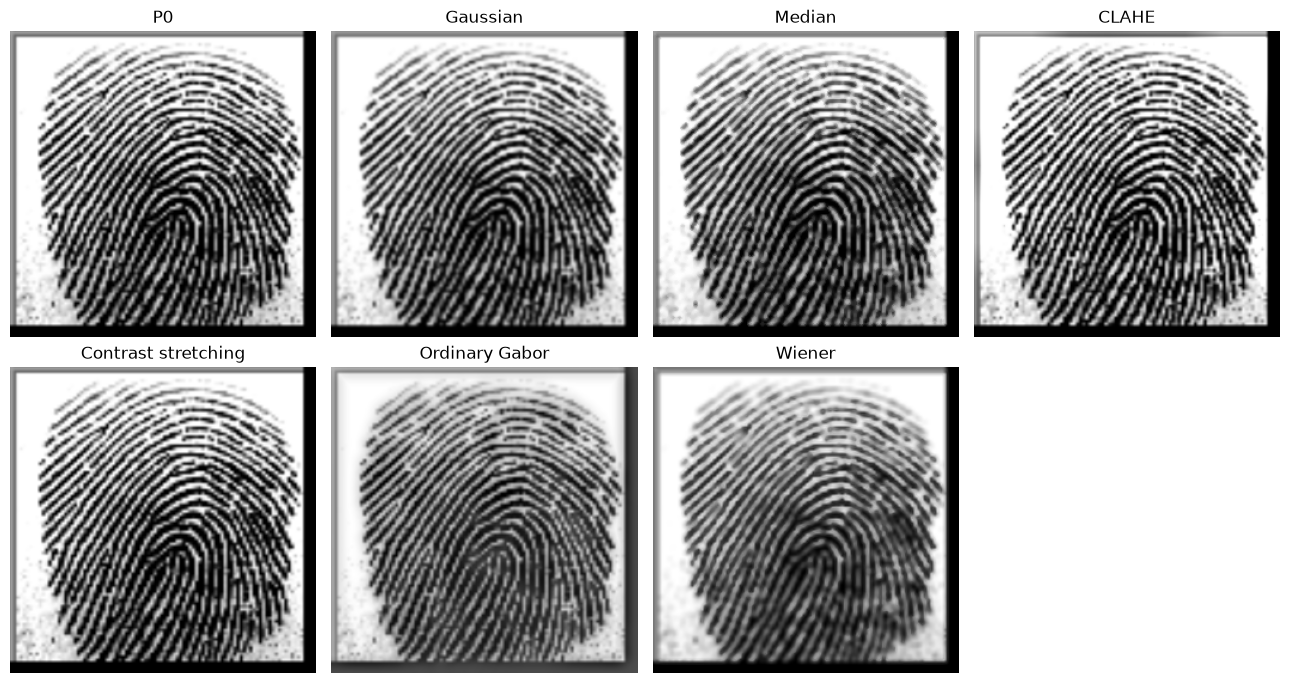

In [5]:
sample_p0 = load_fingerprint(dataset_paths['Real'][0])
baseline_outputs = {'P0': sample_p0, 'Gaussian': apply_gaussian(sample_p0), 'Median': apply_median(sample_p0),
 'CLAHE': apply_clahe(sample_p0), 'Contrast stretching': apply_contrast_stretching(sample_p0),
 'Ordinary Gabor': apply_ordinary_gabor(sample_p0), 'Wiener': apply_wiener(sample_p0)}
fig, axes = plt.subplots(2,4,figsize=(13,7));
for ax,(name,img) in zip(axes.ravel(),baseline_outputs.items()): ax.imshow(img,cmap='gray',vmin=0,vmax=1); ax.set_title(name); ax.axis('off')
axes.ravel()[-1].axis('off'); plt.tight_layout(); plt.show()

## 6. Member 1 — Non-Local Means denoising

`apply_nlm` above is the visible frozen implementation. It searches neighbouring patches and weights them by similarity, suppressing Gaussian noise while retaining repeated ridge texture. The fixed setting is `h=0.06`, converted to 15.3 uint8 units, with template window 7 and search window 21. It is not retuned here.

In [6]:
assert FINAL_NLM_H == 0.06 and NLM_TEMPLATE_WINDOW_SIZE == 7 and NLM_SEARCH_WINDOW_SIZE == 21
nlm_demo = apply_nlm(sample_p0, h=FINAL_NLM_H); print('Frozen M1 implementation ready:', nlm_demo.shape)

Frozen M1 implementation ready: (256, 256)


## 7. Member 2 — Modified / orientation-adaptive Gabor

`_orientation_field`, `_frequency_map`, and `apply_modified_gabor` visibly estimate local ridge orientation and frequency, select among four frequencies and eight orientation bins, and confidence-blend the response. This differs from the fixed ordinary Gabor baseline.

In [7]:
modified_gabor_demo = apply_modified_gabor(sample_p0); print('M2 adaptive output:', modified_gabor_demo.shape)

M2 adaptive output: (256, 256)


## 8. Member 3 — Total Variation restoration

The fixed `apply_tv_restoration(weight=0.02)` uses total-variation regularisation to smooth noise while penalising loss of edge/ridge boundaries.

In [8]:
tv_demo = apply_tv_restoration(sample_p0, weight=0.02); print('M3 TV output:', tv_demo.shape)

M3 TV output: (256, 256)


## 9. Member 4 — Coherence-guided directional diffusion

`_orientation_field`, `_oriented_kernel`, and `apply_coherence_guided_directional_diffusion` explicitly calculate orientation/coherence and repeatedly apply orientation-selected anisotropic smoothing. Fixed parameters are four iterations and step 0.16.

In [9]:
diffusion_demo = apply_coherence_guided_directional_diffusion(sample_p0, iterations=4, step=.16); print('M4 output:', diffusion_demo.shape)

M4 output: (256, 256)


## 10. Structural and downstream processing

The grayscale enhancement is followed, when needed, by segmentation → morphology → thinning/medial axis → feature analysis. These binary operations are not the final grayscale enhancer.

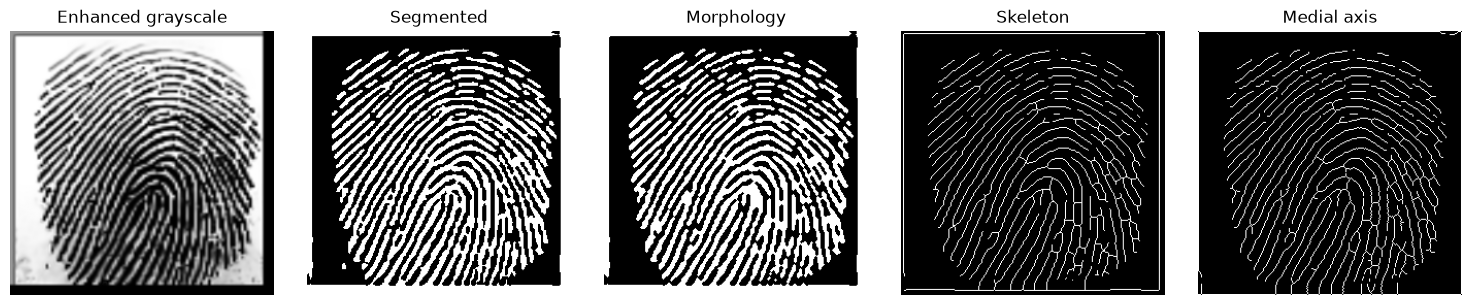

{'ridge_endings': 174, 'bifurcations': 79}


In [10]:
ridges, foreground_mask = segment_fingerprint(nlm_demo)
cleaned = morphological_cleanup(ridges); opened = morphology.opening(cleaned, morphology.disk(1)); closed = morphology.closing(opened, morphology.disk(1))
skeleton = thin_ridges(closed); medial, distance = medial_axis_analysis(closed); minutiae = extract_minutiae_detections(skeleton, foreground_mask)
fig,axes=plt.subplots(1,5,figsize=(15,3));
for ax,(title,img) in zip(axes,[('Enhanced grayscale',nlm_demo),('Segmented',ridges),('Morphology',closed),('Skeleton',skeleton),('Medial axis',medial)]): ax.imshow(img,cmap='gray');ax.set_title(title);ax.axis('off')
plt.tight_layout();plt.show(); print({k:len(v) for k,v in minutiae.items()})

## 11. Evaluation metrics

MSE, PSNR and SSIM are full-reference controlled metrics with data range 1. Structural metrics are used for unpaired original Altered images. Fragmentation is connected components per 1,000 ridge pixels; continuity is skeleton pixels per endpoint.

In [11]:
def structural_metrics(image):
    base = _metric_image(image); mask = _fingerprint_mask(base); local_mean = ndi.uniform_filter(base,17,mode='reflect')
    local_std = np.sqrt(np.maximum(ndi.uniform_filter(base*base,17,mode='reflect')-local_mean*local_mean,0))
    binary,_ = segment_fingerprint(base); labels = measure.label(binary, connectivity=2); props=measure.regionprops(labels)
    skeleton=morphology.skeletonize(binary); points=extract_minutiae_detections(skeleton,mask)
    ridge_pixels=max(int(binary.sum()),1); endpoints=len(points['ridge_endings'])
    return {'coherence':calculate_ridge_coherence(base,mask),'contrast':float(local_std[mask].mean()) if mask.any() else float(local_std.mean()),
            'fragmentation':len(props)/(ridge_pixels/1000.0),'continuity':float(skeleton.sum())/max(endpoints,1),
            'ridge_coverage':float(binary.sum())/max(float(mask.sum()),1.0)}
def full_reference(reference,candidate):
    return {'mse':calculate_mse(reference,candidate),'psnr':calculate_psnr(reference,candidate),'ssim':calculate_ssim(reference,candidate)}
print(full_reference(sample_p0,sample_p0), structural_metrics(sample_p0))

{'mse': 0.0, 'psnr': inf, 'ssim': 1.0} {'coherence': 0.7706694602966309, 'contrast': 0.2295648753643036, 'fragmentation': 1.972386587771203, 'continuity': 36.65432098765432, 'ridge_coverage': 0.4254913330078125}


C:\Users\TARUMT\AppData\Local\Programs\Python\Python311\Lib\site-packages\skimage\metrics\simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


## 12. Controlled degradation

Synthetic degradation is used only for controlled full-reference evaluation, not as the real-world enhancement pipeline. The frozen `gaussian_noise_only_s055` protocol uses severity 0.55, exact sigma 0.04825, deterministic per-image NumPy RNG, and clipping to [0,1].

In [12]:
def controlled_degradation(clean, seed):
    rng=np.random.default_rng(int(seed)); return _metric_image(clean + rng.normal(0.0, GAUSSIAN_SIGMA, clean.shape))
assert abs(GAUSSIAN_SIGMA-0.04825)<1e-15
demo_degraded=controlled_degradation(sample_p0,SEED); display(pd.DataFrame([full_reference(sample_p0,demo_degraded)]))

,mse,psnr,ssim
0,0.001959,27.080727,0.901824


## 13. Four-member controlled comparison

,method,images,PSNR_mean,PSNR_std,MSE_mean,MSE_std,SSIM_mean,SSIM_std
0,M1 NLM,12,29.436598,0.645713,0.001150,0.000164,0.940786,0.014882
1,M3 TV,12,29.185022,0.562663,0.001215,0.000151,0.940203,0.011314
2,M4 Directional Diffusion,12,27.802750,0.697469,0.001678,0.000270,0.868357,0.036982
3,M2 Modified Gabor,12,25.000204,0.586853,0.003188,0.000425,0.837310,0.042086


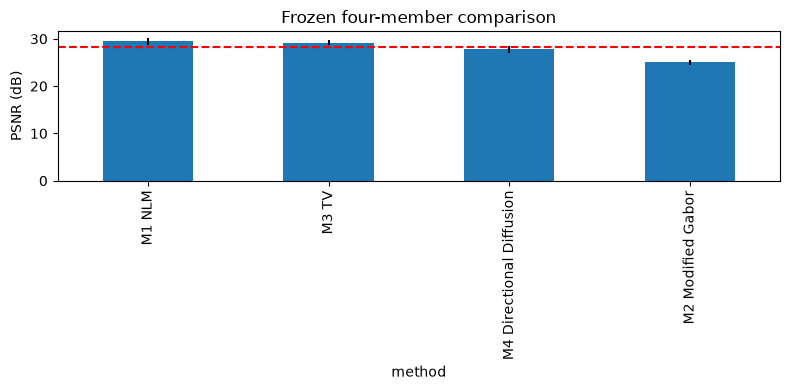

In [13]:
all_real = list_images(REAL_DIR); rng=np.random.default_rng(SEED); indices=np.arange(len(all_real)); rng.shuffle(indices)
development_paths=[all_real[int(i)] for i in indices[:12]]
MEMBER_METHODS={'M1 NLM':lambda x:apply_nlm(x,.06),'M2 Modified Gabor':lambda x:apply_modified_gabor(x),
                'M3 TV':lambda x:apply_tv_restoration(x,.02),'M4 Directional Diffusion':lambda x:apply_coherence_guided_directional_diffusion(x,4,.16)}
member_rows=[]
for i,path in enumerate(development_paths):
    clean=load_fingerprint(path); degraded=controlled_degradation(clean,SEED+i)
    for name,method in MEMBER_METHODS.items(): member_rows.append({'image':path.name,'method':name,**full_reference(clean,method(degraded))})
member_per_image=pd.DataFrame(member_rows)
member_summary=member_per_image.groupby('method').agg(images=('image','count'),PSNR_mean=('psnr','mean'),PSNR_std=('psnr','std'),MSE_mean=('mse','mean'),MSE_std=('mse','std'),SSIM_mean=('ssim','mean'),SSIM_std=('ssim','std')).sort_values('PSNR_mean',ascending=False).reset_index()
display(member_summary); member_summary.to_csv(OUT/'notebook_member_comparison.csv',index=False)
member_summary.plot.bar(x='method',y='PSNR_mean',yerr='PSNR_std',legend=False,figsize=(8,4),ylabel='PSNR (dB)',title='Frozen four-member comparison'); plt.axhline(BENCHMARK_PSNR,color='red',ls='--');plt.tight_layout();plt.show()

## 14. Compatibility / hybrid investigation

,candidate,images,PSNR_mean,PSNR_std,MSE_mean,SSIM_mean
0,C0 NLM,12,29.436598,0.645713,0.001150,0.940786
1,C1 TV -> NLM,12,28.943611,0.346102,0.001279,0.928609
2,C3 NLM -> Directional Diffusion,12,28.296774,0.953702,0.001512,0.932011
3,C4 TV -> NLM -> Directional Diffusion,12,26.609861,0.970276,0.002233,0.910567
4,C2 NLM -> Modified Gabor,12,25.227698,0.809450,0.003047,0.909122


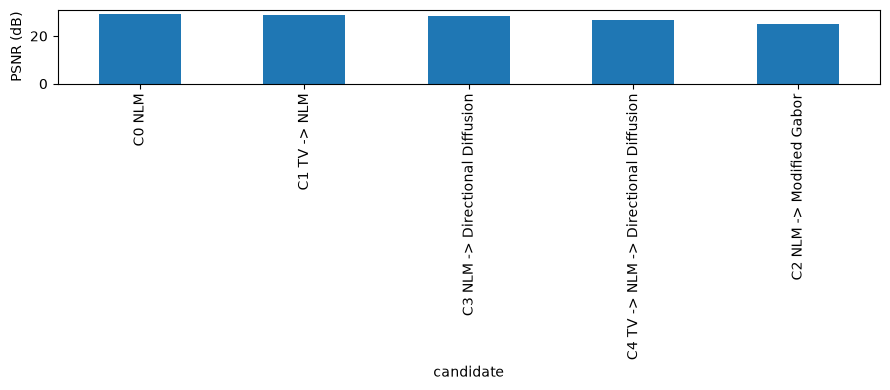

In [14]:
COMPATIBILITY={'C0 NLM':('NLM',),'C1 TV -> NLM':('TV','NLM'),'C2 NLM -> Modified Gabor':('NLM','Gabor'),
 'C3 NLM -> Directional Diffusion':('NLM','Diffusion'),'C4 TV -> NLM -> Directional Diffusion':('TV','NLM','Diffusion')}
def apply_stages(image,stages):
    out=image
    for stage in stages:
        out={'NLM':lambda z:apply_nlm(z,.06),'TV':lambda z:apply_tv_restoration(z,.02),'Gabor':apply_modified_gabor,
             'Diffusion':lambda z:apply_coherence_guided_directional_diffusion(z,4,.16)}[stage](out)
    return out
compat_rows=[]
for i,path in enumerate(development_paths):
    clean=load_fingerprint(path); degraded=controlled_degradation(clean,SEED+i)
    for name,stages in COMPATIBILITY.items(): compat_rows.append({'image':path.name,'candidate':name,**full_reference(clean,apply_stages(degraded,stages))})
compat_per_image=pd.DataFrame(compat_rows)
compat_summary=compat_per_image.groupby('candidate').agg(images=('image','count'),PSNR_mean=('psnr','mean'),PSNR_std=('psnr','std'),MSE_mean=('mse','mean'),SSIM_mean=('ssim','mean')).sort_values('PSNR_mean',ascending=False).reset_index()
display(compat_summary);compat_summary.to_csv(OUT/'notebook_compatibility.csv',index=False)
compat_summary.plot.bar(x='candidate',y='PSNR_mean',legend=False,figsize=(9,4),ylabel='PSNR (dB)');plt.tight_layout();plt.show()

## 15. Final method selection

The result is selected from the recomputed tables, not a stored claim. NLM is retained only if it is the best compatibility candidate; tested extra stages are rejected when they do not improve controlled fidelity.

In [15]:
selected_candidate=compat_summary.iloc[0]['candidate']; assert selected_candidate=='C0 NLM'
print(f'Selected final grayscale method: NLM h={FINAL_NLM_H:.2f}. Best recomputed compatibility candidate: {selected_candidate}.')

Selected final grayscale method: NLM h=0.06. Best recomputed compatibility candidate: C0 NLM.


## 16. Fresh 100-image hold-out validation

In [16]:
FROZEN_HOLDOUT_NAMES = ['586__M_Right_middle_finger.BMP', '541__M_Left_thumb_finger.BMP', '15__F_Left_little_finger.BMP', '586__M_Left_little_finger.BMP', '176__M_Left_index_finger.BMP', '169__F_Left_little_finger.BMP', '67__F_Right_index_finger.BMP', '75__F_Right_thumb_finger.BMP', '61__M_Right_index_finger.BMP', '70__M_Right_index_finger.BMP', '39__M_Right_little_finger.BMP', '536__F_Left_index_finger.BMP', '415__M_Right_middle_finger.BMP', '159__M_Left_little_finger.BMP', '354__M_Left_thumb_finger.BMP', '434__M_Right_index_finger.BMP', '409__M_Left_index_finger.BMP', '40__F_Right_ring_finger.BMP', '207__M_Left_index_finger.BMP', '57__M_Right_ring_finger.BMP', '416__M_Left_thumb_finger.BMP', '344__M_Right_thumb_finger.BMP', '540__F_Right_index_finger.BMP', '184__M_Left_little_finger.BMP', '352__M_Right_ring_finger.BMP', '48__F_Left_little_finger.BMP', '99__M_Left_little_finger.BMP', '243__M_Right_index_finger.BMP', '529__M_Right_thumb_finger.BMP', '547__M_Left_thumb_finger.BMP', '38__M_Right_ring_finger.BMP', '214__M_Right_ring_finger.BMP', '236__M_Right_middle_finger.BMP', '451__M_Right_thumb_finger.BMP', '485__M_Left_little_finger.BMP', '520__M_Right_ring_finger.BMP', '336__M_Right_little_finger.BMP', '306__M_Left_middle_finger.BMP', '503__M_Left_thumb_finger.BMP', '468__F_Right_index_finger.BMP', '86__M_Right_middle_finger.BMP', '554__M_Left_index_finger.BMP', '189__F_Right_little_finger.BMP', '432__M_Left_middle_finger.BMP', '84__M_Right_middle_finger.BMP', '437__M_Left_thumb_finger.BMP', '472__M_Left_little_finger.BMP', '582__M_Right_little_finger.BMP', '460__M_Left_middle_finger.BMP', '242__M_Right_little_finger.BMP', '52__M_Right_ring_finger.BMP', '376__F_Right_little_finger.BMP', '254__M_Left_middle_finger.BMP', '594__M_Left_ring_finger.BMP', '160__M_Right_ring_finger.BMP', '225__M_Right_middle_finger.BMP', '453__F_Right_little_finger.BMP', '209__F_Left_ring_finger.BMP', '600__M_Left_thumb_finger.BMP', '88__F_Left_middle_finger.BMP', '567__M_Left_ring_finger.BMP', '542__M_Right_ring_finger.BMP', '318__F_Right_middle_finger.BMP', '527__M_Right_ring_finger.BMP', '567__M_Right_little_finger.BMP', '350__M_Right_index_finger.BMP', '94__M_Left_middle_finger.BMP', '545__M_Right_middle_finger.BMP', '351__M_Left_middle_finger.BMP', '581__F_Left_index_finger.BMP', '233__M_Left_little_finger.BMP', '348__F_Left_index_finger.BMP', '435__F_Left_ring_finger.BMP', '426__M_Right_little_finger.BMP', '194__M_Left_middle_finger.BMP', '410__M_Right_middle_finger.BMP', '411__M_Left_little_finger.BMP', '558__M_Right_ring_finger.BMP', '420__M_Left_middle_finger.BMP', '387__F_Left_index_finger.BMP', '305__M_Left_little_finger.BMP', '534__F_Right_ring_finger.BMP', '237__M_Left_middle_finger.BMP', '88__F_Right_ring_finger.BMP', '525__M_Right_ring_finger.BMP', '227__M_Left_ring_finger.BMP', '561__M_Left_ring_finger.BMP', '323__M_Right_middle_finger.BMP', '533__M_Right_thumb_finger.BMP', '2__F_Left_little_finger.BMP', '346__M_Left_ring_finger.BMP', '291__M_Right_little_finger.BMP', '9__M_Right_middle_finger.BMP', '294__M_Right_thumb_finger.BMP', '445__M_Right_ring_finger.BMP', '453__F_Right_thumb_finger.BMP', '239__M_Left_index_finger.BMP', '533__M_Left_little_finger.BMP', '98__M_Right_thumb_finger.BMP', '556__F_Left_little_finger.BMP']
holdout_paths=[REAL_DIR/name for name in FROZEN_HOLDOUT_NAMES]; assert len(holdout_paths)==100 and all(p.is_file() for p in holdout_paths)
def controlled_validation(paths, seed_base):
    rows=[]
    for i,path in enumerate(paths):
        clean=load_fingerprint(path); degraded=controlled_degradation(clean,seed_base+i); enhanced=apply_nlm(degraded,.06)
        before=full_reference(clean,degraded); after=full_reference(clean,enhanced)
        rows.append({'filename':path.name,'noise_seed':seed_base+i,**{f'degraded_{k}':v for k,v in before.items()},**{f'enhanced_{k}':v for k,v in after.items()},
                     **{f'delta_{k}':after[k]-before[k] for k in before},'above_28_17':after['psnr']>BENCHMARK_PSNR})
    return pd.DataFrame(rows)
holdout_results=controlled_validation(holdout_paths,NOISE_SEED_BASE)
holdout_summary=holdout_results.agg({'degraded_psnr':['mean','std'],'enhanced_psnr':['mean','std','median','min','max'],'enhanced_mse':['mean'],'enhanced_ssim':['mean'],'delta_psnr':['mean'],'delta_mse':['mean'],'delta_ssim':['mean']})
display(holdout_summary); print(f"Above 28.17 dB: {holdout_results.above_28_17.sum()}/{len(holdout_results)}")
holdout_results.to_csv(OUT/'notebook_fresh_holdout_per_image.csv',index=False)

,degraded_psnr,enhanced_psnr,enhanced_mse,enhanced_ssim,delta_psnr,delta_mse,delta_ssim
mean,27.387560,29.644319,0.001098,0.938317,2.256759,-0.00073,0.103454
std,0.260277,0.675750,NaN,NaN,NaN,NaN,NaN
median,NaN,29.615992,NaN,NaN,NaN,NaN,NaN
min,NaN,28.051874,NaN,NaN,NaN,NaN,NaN
max,NaN,31.851554,NaN,NaN,NaN,NaN,NaN


Above 28.17 dB: 99/100


## 17. Final 500-image robustness validation

In [17]:
FROZEN_CANONICAL_500_NAMES = ['100__M_Left_index_finger.BMP', '100__M_Left_little_finger.BMP', '100__M_Left_middle_finger.BMP', '100__M_Left_ring_finger.BMP', '100__M_Left_thumb_finger.BMP', '100__M_Right_index_finger.BMP', '100__M_Right_little_finger.BMP', '100__M_Right_middle_finger.BMP', '100__M_Right_ring_finger.BMP', '100__M_Right_thumb_finger.BMP', '101__M_Left_index_finger.BMP', '101__M_Left_little_finger.BMP', '101__M_Left_middle_finger.BMP', '101__M_Left_ring_finger.BMP', '101__M_Left_thumb_finger.BMP', '101__M_Right_index_finger.BMP', '101__M_Right_little_finger.BMP', '101__M_Right_middle_finger.BMP', '101__M_Right_ring_finger.BMP', '101__M_Right_thumb_finger.BMP', '102__M_Left_index_finger.BMP', '102__M_Left_little_finger.BMP', '102__M_Left_middle_finger.BMP', '102__M_Left_ring_finger.BMP', '102__M_Left_thumb_finger.BMP', '102__M_Right_index_finger.BMP', '102__M_Right_little_finger.BMP', '102__M_Right_middle_finger.BMP', '102__M_Right_ring_finger.BMP', '102__M_Right_thumb_finger.BMP', '103__F_Left_index_finger.BMP', '103__F_Left_little_finger.BMP', '103__F_Left_middle_finger.BMP', '103__F_Left_ring_finger.BMP', '103__F_Left_thumb_finger.BMP', '103__F_Right_index_finger.BMP', '103__F_Right_little_finger.BMP', '103__F_Right_middle_finger.BMP', '103__F_Right_ring_finger.BMP', '103__F_Right_thumb_finger.BMP', '104__M_Left_index_finger.BMP', '104__M_Left_little_finger.BMP', '104__M_Left_middle_finger.BMP', '104__M_Left_ring_finger.BMP', '104__M_Left_thumb_finger.BMP', '104__M_Right_index_finger.BMP', '104__M_Right_little_finger.BMP', '104__M_Right_middle_finger.BMP', '104__M_Right_ring_finger.BMP', '104__M_Right_thumb_finger.BMP', '105__M_Left_index_finger.BMP', '105__M_Left_little_finger.BMP', '105__M_Left_middle_finger.BMP', '105__M_Left_ring_finger.BMP', '105__M_Left_thumb_finger.BMP', '105__M_Right_index_finger.BMP', '105__M_Right_little_finger.BMP', '105__M_Right_middle_finger.BMP', '105__M_Right_ring_finger.BMP', '105__M_Right_thumb_finger.BMP', '106__M_Left_index_finger.BMP', '106__M_Left_little_finger.BMP', '106__M_Left_middle_finger.BMP', '106__M_Left_ring_finger.BMP', '106__M_Left_thumb_finger.BMP', '106__M_Right_index_finger.BMP', '106__M_Right_little_finger.BMP', '106__M_Right_middle_finger.BMP', '106__M_Right_ring_finger.BMP', '106__M_Right_thumb_finger.BMP', '107__M_Left_index_finger.BMP', '107__M_Left_little_finger.BMP', '107__M_Left_middle_finger.BMP', '107__M_Left_ring_finger.BMP', '107__M_Left_thumb_finger.BMP', '107__M_Right_index_finger.BMP', '107__M_Right_little_finger.BMP', '107__M_Right_middle_finger.BMP', '107__M_Right_ring_finger.BMP', '107__M_Right_thumb_finger.BMP', '108__M_Left_index_finger.BMP', '108__M_Left_little_finger.BMP', '108__M_Left_middle_finger.BMP', '108__M_Left_ring_finger.BMP', '108__M_Left_thumb_finger.BMP', '108__M_Right_index_finger.BMP', '108__M_Right_little_finger.BMP', '108__M_Right_middle_finger.BMP', '108__M_Right_ring_finger.BMP', '108__M_Right_thumb_finger.BMP', '109__F_Left_index_finger.BMP', '109__F_Left_little_finger.BMP', '109__F_Left_middle_finger.BMP', '109__F_Left_ring_finger.BMP', '109__F_Left_thumb_finger.BMP', '109__F_Right_index_finger.BMP', '109__F_Right_little_finger.BMP', '109__F_Right_middle_finger.BMP', '109__F_Right_ring_finger.BMP', '109__F_Right_thumb_finger.BMP', '10__M_Left_index_finger.BMP', '10__M_Left_little_finger.BMP', '10__M_Left_middle_finger.BMP', '10__M_Left_ring_finger.BMP', '10__M_Left_thumb_finger.BMP', '10__M_Right_index_finger.BMP', '10__M_Right_little_finger.BMP', '10__M_Right_middle_finger.BMP', '10__M_Right_ring_finger.BMP', '10__M_Right_thumb_finger.BMP', '110__F_Left_index_finger.BMP', '110__F_Left_little_finger.BMP', '110__F_Left_middle_finger.BMP', '110__F_Left_ring_finger.BMP', '110__F_Left_thumb_finger.BMP', '110__F_Right_index_finger.BMP', '110__F_Right_little_finger.BMP', '110__F_Right_middle_finger.BMP', '110__F_Right_ring_finger.BMP', '110__F_Right_thumb_finger.BMP', '111__M_Left_index_finger.BMP', '111__M_Left_little_finger.BMP', '111__M_Left_middle_finger.BMP', '111__M_Left_ring_finger.BMP', '111__M_Left_thumb_finger.BMP', '111__M_Right_index_finger.BMP', '111__M_Right_little_finger.BMP', '111__M_Right_middle_finger.BMP', '111__M_Right_ring_finger.BMP', '111__M_Right_thumb_finger.BMP', '112__M_Left_index_finger.BMP', '112__M_Left_little_finger.BMP', '112__M_Left_middle_finger.BMP', '112__M_Left_ring_finger.BMP', '112__M_Left_thumb_finger.BMP', '112__M_Right_index_finger.BMP', '112__M_Right_little_finger.BMP', '112__M_Right_middle_finger.BMP', '112__M_Right_ring_finger.BMP', '112__M_Right_thumb_finger.BMP', '113__M_Left_index_finger.BMP', '113__M_Left_little_finger.BMP', '113__M_Left_middle_finger.BMP', '113__M_Left_ring_finger.BMP', '113__M_Left_thumb_finger.BMP', '113__M_Right_index_finger.BMP', '113__M_Right_little_finger.BMP', '113__M_Right_middle_finger.BMP', '113__M_Right_ring_finger.BMP', '113__M_Right_thumb_finger.BMP', '114__F_Left_index_finger.BMP', '114__F_Left_little_finger.BMP', '114__F_Left_middle_finger.BMP', '114__F_Left_ring_finger.BMP', '114__F_Left_thumb_finger.BMP', '114__F_Right_index_finger.BMP', '114__F_Right_little_finger.BMP', '114__F_Right_middle_finger.BMP', '114__F_Right_ring_finger.BMP', '114__F_Right_thumb_finger.BMP', '115__F_Left_index_finger.BMP', '115__F_Left_little_finger.BMP', '115__F_Left_middle_finger.BMP', '115__F_Left_ring_finger.BMP', '115__F_Left_thumb_finger.BMP', '115__F_Right_index_finger.BMP', '115__F_Right_little_finger.BMP', '115__F_Right_middle_finger.BMP', '115__F_Right_ring_finger.BMP', '115__F_Right_thumb_finger.BMP', '116__M_Left_index_finger.BMP', '116__M_Left_little_finger.BMP', '116__M_Left_middle_finger.BMP', '116__M_Left_ring_finger.BMP', '116__M_Left_thumb_finger.BMP', '116__M_Right_index_finger.BMP', '116__M_Right_little_finger.BMP', '116__M_Right_middle_finger.BMP', '116__M_Right_ring_finger.BMP', '116__M_Right_thumb_finger.BMP', '117__F_Left_index_finger.BMP', '117__F_Left_little_finger.BMP', '117__F_Left_middle_finger.BMP', '117__F_Left_ring_finger.BMP', '117__F_Left_thumb_finger.BMP', '117__F_Right_index_finger.BMP', '117__F_Right_little_finger.BMP', '117__F_Right_middle_finger.BMP', '117__F_Right_ring_finger.BMP', '117__F_Right_thumb_finger.BMP', '118__F_Left_index_finger.BMP', '118__F_Left_little_finger.BMP', '118__F_Left_middle_finger.BMP', '118__F_Left_ring_finger.BMP', '118__F_Left_thumb_finger.BMP', '118__F_Right_index_finger.BMP', '118__F_Right_little_finger.BMP', '118__F_Right_middle_finger.BMP', '118__F_Right_ring_finger.BMP', '118__F_Right_thumb_finger.BMP', '119__F_Left_index_finger.BMP', '119__F_Left_little_finger.BMP', '119__F_Left_middle_finger.BMP', '119__F_Left_ring_finger.BMP', '119__F_Left_thumb_finger.BMP', '119__F_Right_index_finger.BMP', '119__F_Right_little_finger.BMP', '119__F_Right_middle_finger.BMP', '119__F_Right_ring_finger.BMP', '119__F_Right_thumb_finger.BMP', '11__M_Left_index_finger.BMP', '11__M_Left_little_finger.BMP', '11__M_Left_middle_finger.BMP', '11__M_Left_ring_finger.BMP', '11__M_Left_thumb_finger.BMP', '11__M_Right_index_finger.BMP', '11__M_Right_little_finger.BMP', '11__M_Right_middle_finger.BMP', '11__M_Right_ring_finger.BMP', '11__M_Right_thumb_finger.BMP', '120__M_Left_index_finger.BMP', '120__M_Left_little_finger.BMP', '120__M_Left_middle_finger.BMP', '120__M_Left_ring_finger.BMP', '120__M_Left_thumb_finger.BMP', '120__M_Right_index_finger.BMP', '120__M_Right_little_finger.BMP', '120__M_Right_middle_finger.BMP', '120__M_Right_ring_finger.BMP', '120__M_Right_thumb_finger.BMP', '121__F_Left_index_finger.BMP', '121__F_Left_little_finger.BMP', '121__F_Left_middle_finger.BMP', '121__F_Left_ring_finger.BMP', '121__F_Left_thumb_finger.BMP', '121__F_Right_index_finger.BMP', '121__F_Right_little_finger.BMP', '121__F_Right_middle_finger.BMP', '121__F_Right_ring_finger.BMP', '121__F_Right_thumb_finger.BMP', '122__M_Left_index_finger.BMP', '122__M_Left_little_finger.BMP', '122__M_Left_middle_finger.BMP', '122__M_Left_ring_finger.BMP', '122__M_Left_thumb_finger.BMP', '122__M_Right_index_finger.BMP', '122__M_Right_little_finger.BMP', '122__M_Right_middle_finger.BMP', '122__M_Right_ring_finger.BMP', '122__M_Right_thumb_finger.BMP', '123__M_Left_index_finger.BMP', '123__M_Left_little_finger.BMP', '123__M_Left_middle_finger.BMP', '123__M_Left_ring_finger.BMP', '123__M_Left_thumb_finger.BMP', '123__M_Right_index_finger.BMP', '123__M_Right_little_finger.BMP', '123__M_Right_middle_finger.BMP', '123__M_Right_ring_finger.BMP', '123__M_Right_thumb_finger.BMP', '124__M_Left_index_finger.BMP', '124__M_Left_little_finger.BMP', '124__M_Left_middle_finger.BMP', '124__M_Left_ring_finger.BMP', '124__M_Left_thumb_finger.BMP', '124__M_Right_index_finger.BMP', '124__M_Right_little_finger.BMP', '124__M_Right_middle_finger.BMP', '124__M_Right_ring_finger.BMP', '124__M_Right_thumb_finger.BMP', '125__M_Left_index_finger.BMP', '125__M_Left_little_finger.BMP', '125__M_Left_middle_finger.BMP', '125__M_Left_ring_finger.BMP', '125__M_Left_thumb_finger.BMP', '125__M_Right_index_finger.BMP', '125__M_Right_little_finger.BMP', '125__M_Right_middle_finger.BMP', '125__M_Right_ring_finger.BMP', '125__M_Right_thumb_finger.BMP', '126__F_Left_index_finger.BMP', '126__F_Left_little_finger.BMP', '126__F_Left_middle_finger.BMP', '126__F_Left_ring_finger.BMP', '126__F_Left_thumb_finger.BMP', '126__F_Right_index_finger.BMP', '126__F_Right_little_finger.BMP', '126__F_Right_middle_finger.BMP', '126__F_Right_ring_finger.BMP', '126__F_Right_thumb_finger.BMP', '127__F_Left_index_finger.BMP', '127__F_Left_little_finger.BMP', '127__F_Left_middle_finger.BMP', '127__F_Left_ring_finger.BMP', '127__F_Left_thumb_finger.BMP', '127__F_Right_index_finger.BMP', '127__F_Right_little_finger.BMP', '127__F_Right_middle_finger.BMP', '127__F_Right_ring_finger.BMP', '127__F_Right_thumb_finger.BMP', '128__M_Left_index_finger.BMP', '128__M_Left_little_finger.BMP', '128__M_Left_middle_finger.BMP', '128__M_Left_ring_finger.BMP', '128__M_Left_thumb_finger.BMP', '128__M_Right_index_finger.BMP', '128__M_Right_little_finger.BMP', '128__M_Right_middle_finger.BMP', '128__M_Right_ring_finger.BMP', '128__M_Right_thumb_finger.BMP', '129__M_Left_index_finger.BMP', '129__M_Left_little_finger.BMP', '129__M_Left_middle_finger.BMP', '129__M_Left_ring_finger.BMP', '129__M_Left_thumb_finger.BMP', '129__M_Right_index_finger.BMP', '129__M_Right_little_finger.BMP', '129__M_Right_middle_finger.BMP', '129__M_Right_ring_finger.BMP', '129__M_Right_thumb_finger.BMP', '12__M_Left_index_finger.BMP', '12__M_Left_little_finger.BMP', '12__M_Left_middle_finger.BMP', '12__M_Left_ring_finger.BMP', '12__M_Left_thumb_finger.BMP', '12__M_Right_index_finger.BMP', '12__M_Right_little_finger.BMP', '12__M_Right_middle_finger.BMP', '12__M_Right_ring_finger.BMP', '12__M_Right_thumb_finger.BMP', '130__F_Left_index_finger.BMP', '130__F_Left_little_finger.BMP', '130__F_Left_middle_finger.BMP', '130__F_Left_ring_finger.BMP', '130__F_Left_thumb_finger.BMP', '130__F_Right_index_finger.BMP', '130__F_Right_little_finger.BMP', '130__F_Right_middle_finger.BMP', '130__F_Right_ring_finger.BMP', '130__F_Right_thumb_finger.BMP', '131__M_Left_index_finger.BMP', '131__M_Left_little_finger.BMP', '131__M_Left_middle_finger.BMP', '131__M_Left_ring_finger.BMP', '131__M_Left_thumb_finger.BMP', '131__M_Right_index_finger.BMP', '131__M_Right_little_finger.BMP', '131__M_Right_middle_finger.BMP', '131__M_Right_ring_finger.BMP', '131__M_Right_thumb_finger.BMP', '132__M_Left_index_finger.BMP', '132__M_Left_little_finger.BMP', '132__M_Left_middle_finger.BMP', '132__M_Left_ring_finger.BMP', '132__M_Left_thumb_finger.BMP', '132__M_Right_index_finger.BMP', '132__M_Right_little_finger.BMP', '132__M_Right_middle_finger.BMP', '132__M_Right_ring_finger.BMP', '132__M_Right_thumb_finger.BMP', '133__M_Left_index_finger.BMP', '133__M_Left_little_finger.BMP', '133__M_Left_middle_finger.BMP', '133__M_Left_ring_finger.BMP', '133__M_Left_thumb_finger.BMP', '133__M_Right_index_finger.BMP', '133__M_Right_little_finger.BMP', '133__M_Right_middle_finger.BMP', '133__M_Right_ring_finger.BMP', '133__M_Right_thumb_finger.BMP', '134__M_Left_index_finger.BMP', '134__M_Left_little_finger.BMP', '134__M_Left_middle_finger.BMP', '134__M_Left_ring_finger.BMP', '134__M_Left_thumb_finger.BMP', '134__M_Right_index_finger.BMP', '134__M_Right_little_finger.BMP', '134__M_Right_middle_finger.BMP', '134__M_Right_ring_finger.BMP', '134__M_Right_thumb_finger.BMP', '135__F_Left_index_finger.BMP', '135__F_Left_little_finger.BMP', '135__F_Left_middle_finger.BMP', '135__F_Left_ring_finger.BMP', '135__F_Left_thumb_finger.BMP', '135__F_Right_index_finger.BMP', '135__F_Right_little_finger.BMP', '135__F_Right_middle_finger.BMP', '135__F_Right_ring_finger.BMP', '135__F_Right_thumb_finger.BMP', '136__F_Left_index_finger.BMP', '136__F_Left_little_finger.BMP', '136__F_Left_middle_finger.BMP', '136__F_Left_ring_finger.BMP', '136__F_Left_thumb_finger.BMP', '136__F_Right_index_finger.BMP', '136__F_Right_little_finger.BMP', '136__F_Right_middle_finger.BMP', '136__F_Right_ring_finger.BMP', '136__F_Right_thumb_finger.BMP', '137__M_Left_index_finger.BMP', '137__M_Left_little_finger.BMP', '137__M_Left_middle_finger.BMP', '137__M_Left_ring_finger.BMP', '137__M_Left_thumb_finger.BMP', '137__M_Right_index_finger.BMP', '137__M_Right_little_finger.BMP', '137__M_Right_middle_finger.BMP', '137__M_Right_ring_finger.BMP', '137__M_Right_thumb_finger.BMP', '138__M_Left_index_finger.BMP', '138__M_Left_little_finger.BMP', '138__M_Left_middle_finger.BMP', '138__M_Left_ring_finger.BMP', '138__M_Left_thumb_finger.BMP', '138__M_Right_index_finger.BMP', '138__M_Right_little_finger.BMP', '138__M_Right_middle_finger.BMP', '138__M_Right_ring_finger.BMP', '138__M_Right_thumb_finger.BMP', '139__M_Left_index_finger.BMP', '139__M_Left_little_finger.BMP', '139__M_Left_middle_finger.BMP', '139__M_Left_ring_finger.BMP', '139__M_Left_thumb_finger.BMP', '139__M_Right_index_finger.BMP', '139__M_Right_little_finger.BMP', '139__M_Right_middle_finger.BMP', '139__M_Right_ring_finger.BMP', '139__M_Right_thumb_finger.BMP', '13__F_Left_index_finger.BMP', '13__F_Left_little_finger.BMP', '13__F_Left_middle_finger.BMP', '13__F_Left_ring_finger.BMP', '13__F_Left_thumb_finger.BMP', '13__F_Right_index_finger.BMP', '13__F_Right_little_finger.BMP', '13__F_Right_middle_finger.BMP', '13__F_Right_ring_finger.BMP', '13__F_Right_thumb_finger.BMP', '140__F_Left_index_finger.BMP', '140__F_Left_little_finger.BMP', '140__F_Left_middle_finger.BMP', '140__F_Left_ring_finger.BMP', '140__F_Left_thumb_finger.BMP', '140__F_Right_index_finger.BMP', '140__F_Right_little_finger.BMP', '140__F_Right_middle_finger.BMP', '140__F_Right_ring_finger.BMP', '140__F_Right_thumb_finger.BMP', '141__F_Left_index_finger.BMP', '141__F_Left_little_finger.BMP', '141__F_Left_middle_finger.BMP', '141__F_Left_ring_finger.BMP', '141__F_Left_thumb_finger.BMP', '141__F_Right_index_finger.BMP', '141__F_Right_little_finger.BMP', '141__F_Right_middle_finger.BMP', '141__F_Right_ring_finger.BMP', '141__F_Right_thumb_finger.BMP', '142__F_Left_index_finger.BMP', '142__F_Left_little_finger.BMP', '142__F_Left_middle_finger.BMP', '142__F_Left_ring_finger.BMP', '142__F_Left_thumb_finger.BMP', '142__F_Right_index_finger.BMP', '142__F_Right_little_finger.BMP', '142__F_Right_middle_finger.BMP', '142__F_Right_ring_finger.BMP', '142__F_Right_thumb_finger.BMP', '143__M_Left_index_finger.BMP', '143__M_Left_little_finger.BMP', '143__M_Left_middle_finger.BMP', '143__M_Left_ring_finger.BMP', '143__M_Left_thumb_finger.BMP', '143__M_Right_index_finger.BMP', '143__M_Right_little_finger.BMP', '143__M_Right_middle_finger.BMP', '143__M_Right_ring_finger.BMP', '143__M_Right_thumb_finger.BMP', '144__M_Left_index_finger.BMP', '144__M_Left_little_finger.BMP', '144__M_Left_middle_finger.BMP', '144__M_Left_ring_finger.BMP', '144__M_Left_thumb_finger.BMP', '144__M_Right_index_finger.BMP', '144__M_Right_little_finger.BMP', '144__M_Right_middle_finger.BMP', '144__M_Right_ring_finger.BMP', '144__M_Right_thumb_finger.BMP', '145__M_Left_index_finger.BMP', '145__M_Left_little_finger.BMP', '145__M_Left_middle_finger.BMP', '145__M_Left_ring_finger.BMP', '145__M_Left_thumb_finger.BMP', '145__M_Right_index_finger.BMP', '145__M_Right_little_finger.BMP', '145__M_Right_middle_finger.BMP', '145__M_Right_ring_finger.BMP', '145__M_Right_thumb_finger.BMP']
large_paths=[REAL_DIR/name for name in FROZEN_CANONICAL_500_NAMES]; assert len(large_paths)==500 and len(set(large_paths))==500 and all(p.is_file() for p in large_paths)
large_results=controlled_validation(large_paths,NOISE_SEED_BASE)
large_stats={'count':len(large_results),'mean_psnr':large_results.enhanced_psnr.mean(),'std_psnr':large_results.enhanced_psnr.std(),
 'median_psnr':large_results.enhanced_psnr.median(),'min_psnr':large_results.enhanced_psnr.min(),'max_psnr':large_results.enhanced_psnr.max(),
 'mean_mse':large_results.enhanced_mse.mean(),'mean_ssim':large_results.enhanced_ssim.mean(),'above_28_17':int(large_results.above_28_17.sum())}
large_stats['percentage_above_28_17']=100*large_stats['above_28_17']/large_stats['count'];large_stats['margin_to_benchmark']=large_stats['mean_psnr']-BENCHMARK_PSNR
display(pd.DataFrame([large_stats])); large_results.to_csv(OUT/'notebook_final_500_per_image.csv',index=False)

,count,mean_psnr,std_psnr,median_psnr,min_psnr,max_psnr,mean_mse,mean_ssim,above_28_17,percentage_above_28_17,margin_to_benchmark
0,500,29.630294,0.62464,29.571109,28.417826,31.746032,0.0011,0.935714,500,100.0,1.460294


## 18. Original Altered large validation

Exactly 500 images per difficulty are deterministically selected and processed directly: Original Altered → P0 → NLM. No synthetic noise and no unverified paired reference are used.

In [18]:
altered_rows=[]; selected_altered={}
for offset,severity in enumerate(('Easy','Medium','Hard')):
    candidates=dataset_paths[severity]; rng=np.random.default_rng(ALTERED_SEED+offset)
    paths=[candidates[int(i)] for i in rng.permutation(len(candidates))[:500]];selected_altered[severity]=paths
    for path in paths:
        before=load_fingerprint(path);after=apply_nlm(before,.06);bm=structural_metrics(before);am=structural_metrics(after)
        altered_rows.append({'severity':severity,'filename':path.name,**{f'{k}_before':v for k,v in bm.items()},**{f'{k}_after':v for k,v in am.items()},**{f'delta_{k}':am[k]-bm[k] for k in bm}})
altered_results=pd.DataFrame(altered_rows)
altered_summary=[]
for label,group in [(s,altered_results[altered_results.severity.eq(s)]) for s in ('Easy','Medium','Hard')]+[('Overall',altered_results)]:
    altered_summary.append({'severity':label,'count':len(group),**{f'mean_{c}':group[c].mean() for c in group.columns if c.startswith(('coherence_','contrast_','fragmentation_','continuity_','ridge_coverage_','delta_'))}})
altered_summary=pd.DataFrame(altered_summary);display(altered_summary[['severity','count','mean_delta_coherence','mean_delta_contrast','mean_delta_fragmentation','mean_delta_continuity','mean_delta_ridge_coverage']])
altered_results.to_csv(OUT/'notebook_altered_1500_per_image.csv',index=False);altered_summary.to_csv(OUT/'notebook_altered_1500_summary.csv',index=False)

,severity,count,mean_delta_coherence,mean_delta_contrast,mean_delta_fragmentation,mean_delta_continuity,mean_delta_ridge_coverage
0,Easy,500,0.054444,-0.005166,-0.098401,3.334502,-0.003775
1,Medium,500,0.057070,-0.005683,-0.121987,2.869219,-0.003786
2,Hard,500,0.060220,-0.006133,-0.162777,3.011087,-0.004167
3,Overall,1500,0.057245,-0.005661,-0.127722,3.071603,-0.003909


## 19. Representative visual results

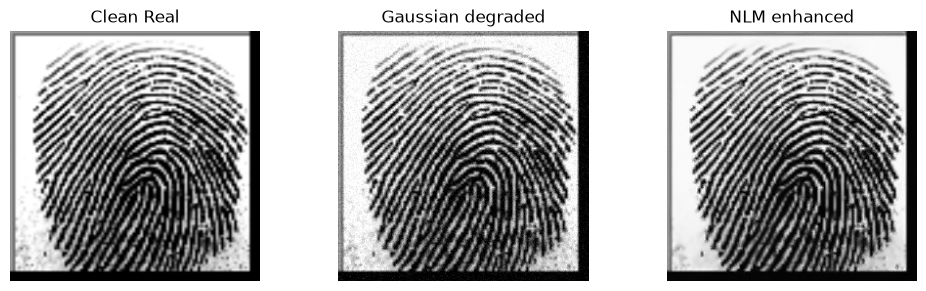

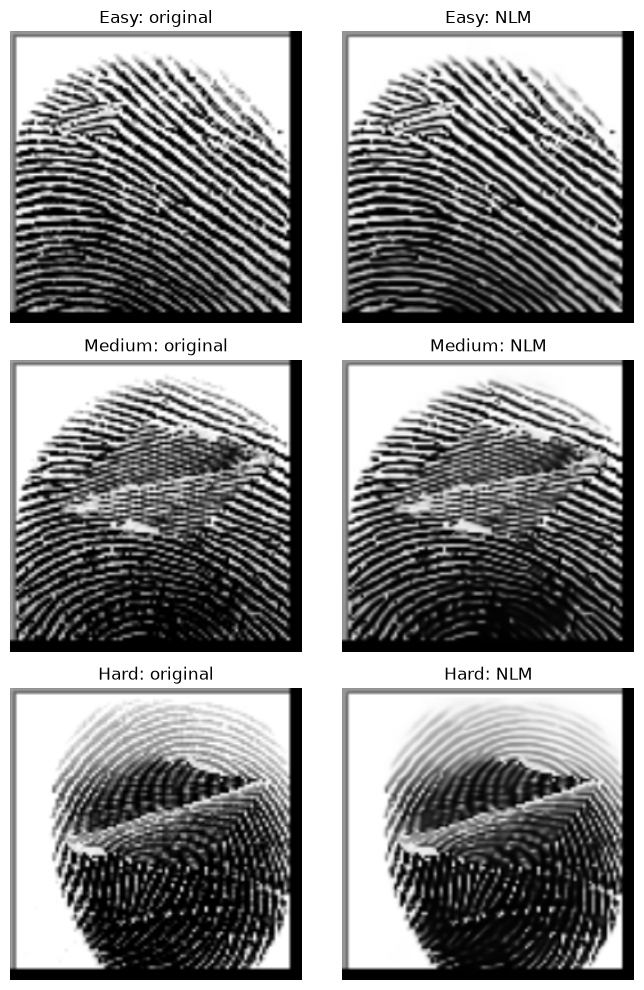

In [19]:
fig,axes=plt.subplots(1,3,figsize=(10,3));clean=load_fingerprint(large_paths[0]);degraded=controlled_degradation(clean,NOISE_SEED_BASE);enhanced=apply_nlm(degraded,.06)
for ax,(title,img) in zip(axes,[('Clean Real',clean),('Gaussian degraded',degraded),('NLM enhanced',enhanced)]):ax.imshow(img,cmap='gray',vmin=0,vmax=1);ax.set_title(title);ax.axis('off')
plt.tight_layout();plt.show()
fig,axes=plt.subplots(3,2,figsize=(7,10))
for row,severity in enumerate(('Easy','Medium','Hard')):
    before=load_fingerprint(selected_altered[severity][0]);after=apply_nlm(before,.06)
    for ax,title,img in [(axes[row,0],f'{severity}: original',before),(axes[row,1],f'{severity}: NLM',after)]:ax.imshow(img,cmap='gray',vmin=0,vmax=1);ax.set_title(title);ax.axis('off')
plt.tight_layout();plt.show()

## 20. Final results table

In [20]:
overall_alt=altered_summary.query("severity=='Overall'").iloc[0]
final_results=pd.DataFrame([
 {'experiment':'Member comparison — best','result':member_summary.iloc[0].method,'PSNR_dB':member_summary.iloc[0].PSNR_mean,'count':int(member_summary.iloc[0].images)},
 {'experiment':'Compatibility — best','result':compat_summary.iloc[0].candidate,'PSNR_dB':compat_summary.iloc[0].PSNR_mean,'count':int(compat_summary.iloc[0].images)},
 {'experiment':'Fresh hold-out','result':f"{int(holdout_results.above_28_17.sum())}/100 above 28.17",'PSNR_dB':holdout_results.enhanced_psnr.mean(),'count':100},
 {'experiment':'Final robustness','result':f"{large_stats['above_28_17']}/500 above 28.17",'PSNR_dB':large_stats['mean_psnr'],'count':500},
 {'experiment':'Original Altered','result':f"Δcoh={overall_alt.mean_delta_coherence:+.5f}; Δfrag={overall_alt.mean_delta_fragmentation:+.5f}; Δcontrast={overall_alt.mean_delta_contrast:+.5f}",'PSNR_dB':np.nan,'count':1500}])
display(final_results);final_results.to_csv(OUT/'notebook_final_results_table.csv',index=False)

,experiment,result,PSNR_dB,count
0,Member comparison — best,M1 NLM,29.436598,12
1,Compatibility — best,C0 NLM,29.436598,12
2,Fresh hold-out,99/100 above 28.17,29.644319,100
3,Final robustness,500/500 above 28.17,29.630294,500
4,Original Altered,Δcoh=+0.05724; Δfrag=-0.12772; Δcontrast=-0.00566,NaN,1500


## 21. Results and discussion

NLM is expected to lead under additive Gaussian noise because patch recurrence is strong in fingerprint ridges and its similarity averaging removes noise without imposing a single ridge orientation. TV remains competitive because its regulariser suppresses noise while preserving strong boundaries. Adaptive Gabor deliberately changes ridge-frequency content and therefore may look structurally useful while scoring lower in pixel fidelity. Directional diffusion can improve local ridge-flow structure but repeated smoothing can reduce PSNR. The compatibility table demonstrates that extra stages do not automatically help: their transformations accumulate bias after NLM.

The fresh hold-out and 500-image runs test generalisation and robustness with frozen settings. The Altered experiment must be read metric by metric; any coherence or fragmentation gain is reported alongside, not instead of, the observed contrast trade-off.

In [21]:
display(Markdown(f'''The fresh hold-out regenerated **{holdout_results.enhanced_psnr.mean():.4f} dB** with **{int(holdout_results.above_28_17.sum())}/100** above 28.17 dB. The 500-image mean was **{large_stats['mean_psnr']:.4f} dB**, with **{large_stats['above_28_17']}/500** above the benchmark. On 1,500 original Altered images, mean deltas were coherence **{overall_alt.mean_delta_coherence:+.5f}**, fragmentation **{overall_alt.mean_delta_fragmentation:+.5f}**, and contrast **{overall_alt.mean_delta_contrast:+.5f}**.'''))

The fresh hold-out regenerated **29.6443 dB** with **99/100** above 28.17 dB. The 500-image mean was **29.6303 dB**, with **500/500** above the benchmark. On 1,500 original Altered images, mean deltas were coherence **+0.05724**, fragmentation **-0.12772**, and contrast **-0.00566**.

## 22. Literature benchmark

The selected article reports PSNR 28.17 dB and MSE 22.27. Under this project's controlled Gaussian-noise protocol, the fixed final NLM is compared with the PSNR benchmark. This is not a claim of identical experimental conditions. Direct MSE superiority is not claimed because image scale and protocol equivalence are not established.

In [22]:
print(f"Controlled 500-image mean margin over 28.17 dB: {large_stats['margin_to_benchmark']:+.4f} dB")

Controlled 500-image mean margin over 28.17 dB: +1.4603 dB


## 23. Final pipeline

**Fingerprint image → P0 neutral preprocessing → NLM (`h=0.06`) → enhanced grayscale fingerprint**

Optional downstream path: **enhanced fingerprint → segmentation → morphology → thinning / medial axis → feature analysis**.

## 24. Conclusion

In [23]:
display(Markdown(f'''The recomputed evidence selects **NLM h={FINAL_NLM_H:.2f}** as the final grayscale method. It led the frozen member and compatibility comparisons, generalised to a fresh 100-image set, and achieved **{large_stats['mean_psnr']:.4f} dB** over 500 Real images ({large_stats['above_28_17']}/500 above 28.17 dB). The unpaired Altered evaluation processed 1,500 originals and showed coherence, fragmentation and contrast deltas of **{overall_alt.mean_delta_coherence:+.5f}**, **{overall_alt.mean_delta_fragmentation:+.5f}**, and **{overall_alt.mean_delta_contrast:+.5f}**, respectively. Structural processing remains optional and downstream.'''))

The recomputed evidence selects **NLM h=0.06** as the final grayscale method. It led the frozen member and compatibility comparisons, generalised to a fresh 100-image set, and achieved **29.6303 dB** over 500 Real images (500/500 above 28.17 dB). The unpaired Altered evaluation processed 1,500 originals and showed coherence, fragmentation and contrast deltas of **+0.05724**, **-0.12772**, and **-0.00566**, respectively. Structural processing remains optional and downstream.